# Test: anisotropic flux loss

Loads selected models × timestamps via `utils/results_subset_loader.py`.


In [71]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('notebooks') if Path('notebooks').exists() else NOTEBOOK_DIR
sys.path.insert(0, str((NOTEBOOK_DIR / '..').resolve()))

from utils.results_subset_loader import (
    index_path_for,
    load_results_index,
    load_results_subset,
)

RESULTS_FILE = (NOTEBOOK_DIR / '../outputs/Our_results_trained_models_2mT.pkl').resolve()
OUTPUT_DIR = (NOTEBOOK_DIR / '../outputs').resolve()
TARGET_VAR = '2mT'
PLOT_VAR = '2mT'
GT_MODEL = 'COSMO-CLM'
COMPUTE_FLUX_MSE = True
FORCE_REBUILD_SUBSET = False

index = load_results_index(RESULTS_FILE)
if index is not None:
    available_models = index['models']
    available_times = [pd.Timestamp(t) for t in index['time_steps']]
    print(f'Index: {index_path_for(RESULTS_FILE)} ({index["n_rows"]} rows in source)')
else:
    available_models, available_times = [], []
    print('No index yet — built on first subset-cache extraction.')

if index is not None and GT_MODEL is not None and GT_MODEL not in available_models:
    print(f'Warning: GT_MODEL={GT_MODEL!r} not in index; flux MSE may fail after load.')

if RESULTS_FILE.is_file():
    print(f'Source: {RESULTS_FILE} ({RESULTS_FILE.stat().st_size / 2**30:.2f} GiB)')


Index: /home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/outputs/Our_results_trained_models_2mT.index.json (2475 rows in source)
Source: /home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/outputs/Our_results_trained_models_2mT.pkl (3.57 GiB)


## Models and timestamps


In [ ]:
SKIP_MODELS = set()
# Names must match outputs/Our_results_trained_models_2mT.index.json (e.g. *_inv_ni suffix).
model_order = ['COSMO-CLM', 'LMM_PDE_res_020_3_inv_ni']
exclude_models = []

time_slices = [
    '2014-04-24 02:00:00',
    # '2014-12-28 03:00:00',
    # '2016-05-02 04:00:00',
    # '2006-05-14 10:00:00',
    # '2019-09-02 02:00:00',
]
selected_times = pd.to_datetime(time_slices)

# Grid spacing [m] EPSG:3035 — edit here (prototype; plotting_utils does not compute flux)
DX_HIGH, DY_HIGH = 2000.0, -2000.0   # y decreases with row index on HR grid
DX_LOW, DY_LOW = 16000.0, -16000.0
dx, dy = DX_HIGH, DY_HIGH
grad_eps = 1e-6


# Quiver: lens remaps arrow lengths for visibility (γ, min/max frac). False = raw qx/qy.
USE_QUIVER_LENS = True

# |q| mask for flux quiver panels (per model × time slice): skip bottom X% smallest |q|.
# 0 = off; 50 = hide weakest half (purple dots at skipped grid points).
Q_MASK_SKIP_QUANTILE_PCT = 50.0

# Panel G — deep zoom on q (EPSG:3035 m). Tighter box + smaller stride = denser arrows.
Q_DEEP_ZOOM_X = (4_225_000.0, 4_375_000.0)
Q_DEEP_ZOOM_Y = (1_828_500.0, 1_989_500.0)
Q_DEEP_ZOOM_STRIDE = 3

HR_SHAPE = (672, 576)

BORDERS_FILE = (NOTEBOOK_DIR / '../LDM-downscaling/full_Dataset/plotting_resources/borders_downscaling_domain_3035.geojson').resolve()
if not BORDERS_FILE.is_file():
    BORDERS_FILE = (NOTEBOOK_DIR / '../data/plotting_resources/borders_domain_EPSG3035.geojson').resolve()
    if not BORDERS_FILE.is_file():
        BORDERS_FILE = None


def resolve_models(available, model_order=None, skip=None, exclude=None):
    skip, exclude = set(skip or []), set(exclude or [])
    models = (
        [m for m in model_order if m not in exclude and m not in skip]
        if model_order is not None
        else [m for m in sorted(available) if m not in skip and m not in exclude]
    )
    missing = [m for m in models if m not in set(available)]
    if missing:
        raise ValueError(f'Missing models: {missing}')
    if not models:
        raise ValueError('No models to plot.')
    return models


def _planned_plot_models():
    skip, exclude = set(SKIP_MODELS), set(exclude_models)
    if model_order is not None:
        return [m for m in model_order if m not in exclude and m not in skip]
    return [m for m in sorted(available_models) if m not in skip and m not in exclude]


planned = _planned_plot_models()
print('Will load from pickle:', planned)




Will load from pickle: ['COSMO-CLM', 'LMM_PDE_res_020_3_inv_ni']


## Load subset cache

First run: one full-pickle read (torch required). Later runs: fast.


In [123]:
# Use model_order directly when index is missing; subset load validates against pickle
models_to_load = _planned_plot_models()
if available_models:
    models_to_load = resolve_models(available_models, model_order, SKIP_MODELS, exclude_models)
if GT_MODEL is not None and GT_MODEL not in models_to_load:
    models_to_load = [GT_MODEL] + models_to_load

plot_df = load_results_subset(
    RESULTS_FILE,
    models=models_to_load,
    times=selected_times,
    target_var=TARGET_VAR,
    plot_var=PLOT_VAR,
    force_rebuild=FORCE_REBUILD_SUBSET,
)
models_to_plot = resolve_models(plot_df['model'].unique(), model_order, SKIP_MODELS, exclude_models)
print(f'Ready: {len(plot_df)} rows; plot models: {models_to_plot}')

Loaded subset cache (1.8 MiB, 2 rows): /home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/outputs/Our_results_trained_models_2mT_subset_4c8cd9aff0cba265
Ready: 2 rows; plot models: ['COSMO-CLM', 'LMM_PDE_res_020_3_inv_ni']


In [124]:
def as_array(value) -> np.ndarray:
    if isinstance(value, (list, tuple)) and len(value) == 1:
        value = value[0]
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    elif hasattr(value, 'values'):
        value = value.values
    arr = np.asarray(value, dtype=float).squeeze()
    if arr.ndim != 2:
        raise ValueError(f'Expected 2-D field, got shape {arr.shape}')
    return arr


def get_temperature_field(df, model: str, ts) -> np.ndarray:
    ts = pd.to_datetime(ts)
    row = df[(df['model'] == model) & (df['time_step'] == ts)]
    if row.empty:
        raise KeyError(f'No row for model={model!r}, time={ts}')
    return as_array(row.iloc[0]['spat_distr'])


def upsample_to_reference_grid(field: np.ndarray, ref_shape: tuple[int, int], label: str = '') -> np.ndarray:
    if field.shape == ref_shape:
        return field
    h, w = field.shape
    rh, rw = ref_shape[0] // h, ref_shape[1] // w
    if rh * h == ref_shape[0] and rw * w == ref_shape[1]:
        return np.repeat(np.repeat(field, rh, axis=0), rw, axis=1)
    raise ValueError(
        f'Cannot align {label or "field"} shape {field.shape} to reference {ref_shape}.'
    )





def validate_times(df, times):
    available_times = set(pd.to_datetime(df['time_step']))
    missing = [ts for ts in times if pd.to_datetime(ts) not in available_times]
    if missing:
        raise ValueError(f'Missing timestamps: {missing}')



## Flux physics (notebook only)

Naming (avoid mixing with real conductive tensor **K**):

- **K** (not computed): true conductivity tensor in the full formulation.
- **J** = ∇T ∇Tᵀ: **recovered** rank-1 conductivity proxy (`J_xx`, `J_xy`, `J_yy`).
- **q** = −J @ ∇T.
- **J_trace** = trace(J) = |∇T|²: scalar field for overlay panels (summary of J).


In [125]:
def compute_gradients(T, dx=1.0, dy=1.0, scalar=10**2):
    """∇T via central differences; T shape (H, W) = (y, x)."""
    T = np.asarray(T, dtype=float)
    H, W = T.shape
    dTdx = np.zeros_like(T)
    dTdy = np.zeros_like(T)
    if W > 2:
        dTdx[:, 1:-1] = (T[:, 2:] - T[:, :-2]) / (2.0 * dx)
    if H > 2:
        dTdy[1:-1, :] = (T[2:, :] - T[:-2, :]) / (2.0 * dy)
    if W > 1:
        dTdx[:, 0] = (T[:, 1] - T[:, 0]) / dx
        dTdx[:, -1] = (T[:, -1] - T[:, -2]) / dx
    if H > 1:
        dTdy[0, :] = (T[1, :] - T[0, :]) / dy
        dTdy[-1, :] = (T[-1, :] - T[-2, :]) / dy

    dTdx*= scalar
    dTdy*= scalar
    return dTdx, dTdy


def compute_flux_fields(T, dx=1.0, dy=1.0, eps=1e-6):
    """Per grid point: q = -J @ grad with recovered J = grad @ grad.T.

    grad = [gx, gy] = [dTdx, dTdy]
    J = [[J_xx, J_xy], [J_xy, J_yy]]  (recovered proxy; not real conductive K)
    q = -J @ grad  =>  |q| = |grad|^3  (rank-1 J).

    Magnitudes **without** eps inside sqrt (for histograms / MSE). ``eps`` is kept only
    for legacy floored fields ``grad_mag_eps`` / ``q_mag_eps`` (sqrt(· + eps)).
    """
    T = np.asarray(T, dtype=float)
    dTdx, dTdy = compute_gradients(T, dx=dx, dy=dy)
    gx, gy = dTdx, dTdy

    J_xx = gx * gx
    J_xy = gx * gy
    J_yy = gy * gy

    qx = -(J_xx * gx + J_xy * gy)
    qy = -(J_xy * gx + J_yy * gy)
    J_trace = J_xx + J_yy

    grad_mag = np.hypot(gx, gy)
    q_mag = np.hypot(qx, qy)

    return {
        'T': T,
        'dTdx': dTdx,
        'dTdy': dTdy,
        'J_xx': J_xx,
        'J_xy': J_xy,
        'J_yy': J_yy,
        'J_trace': J_trace,
        'grad_mag': grad_mag,
        'q_mag': q_mag,
        'grad_mag_eps': np.sqrt(J_trace + eps),
        'q_mag_eps': np.sqrt(qx ** 2 + qy ** 2 + eps),
        'qx': qx,
        'qy': qy,
    }


def compute_q_field(T, dx=1.0, dy=1.0, eps=1e-6):
    f = compute_flux_fields(T, dx=dx, dy=dy, eps=eps)
    return f['qx'], f['qy'], f['q_mag'], f['dTdx'], f['dTdy']



## Flux loss definitions (notebook-local test only)

Not in `utils` — run this cell before **Flux loss vs ground truth**.

- $\mathcal{L}_{mag} = \mathrm{MSE}(\log(|q_{pred}|+\epsilon), \log(|q_{gt}|+\epsilon))$
- $\mathcal{L}_{dir}$: cosine or unit-vector MSE (`FLUX_DIR_LOSS`)
- $\mathcal{L} = \lambda_1 \mathcal{L}_{mag} + \lambda_2 \mathcal{L}_{dir}$


In [126]:
# --- hyperparameters (notebook-local) ---
FLUX_LAMBDA_MAG = 1.0
FLUX_LAMBDA_DIR = 1.0
FLUX_LOSS_EPS = 1e-12
FLUX_DIR_LOSS = 'unit_mse'   # 'cosine' or 'unit_mse'


def _flux_mag(qx, qy):
    return np.hypot(np.asarray(qx, float), np.asarray(qy, float))


def _flux_unit(qx, qy, eps=FLUX_LOSS_EPS):
    qx = np.asarray(qx, dtype=float)
    qy = np.asarray(qy, dtype=float)
    mag = _flux_mag(qx, qy)
    return qx / (mag + eps), qy / (mag + eps)


def flux_log_magnitude_loss(q_pred_x, q_pred_y, q_gt_x, q_gt_y, eps=FLUX_LOSS_EPS) -> float:
    mag_p = _flux_mag(q_pred_x, q_pred_y)
    mag_g = _flux_mag(q_gt_x, q_gt_y)
    return float(np.mean((np.log(mag_p + eps) - np.log(mag_g + eps)) ** 2))


def flux_direction_loss_cosine(q_pred_x, q_pred_y, q_gt_x, q_gt_y, eps=FLUX_LOSS_EPS) -> float:
    qx_p, qy_p = np.asarray(q_pred_x, float), np.asarray(q_pred_y, float)
    qx_g, qy_g = np.asarray(q_gt_x, float), np.asarray(q_gt_y, float)
    dot = qx_p * qx_g + qy_p * qy_g
    mag_p, mag_g = _flux_mag(qx_p, qy_p), _flux_mag(qx_g, qy_g)
    return float(np.mean(1.0 - dot / (mag_p * mag_g + eps)))


def flux_direction_loss_unit_mse(q_pred_x, q_pred_y, q_gt_x, q_gt_y, eps=FLUX_LOSS_EPS) -> float:
    px, py = _flux_unit(q_pred_x, q_pred_y, eps=eps)
    gx, gy = _flux_unit(q_gt_x, q_gt_y, eps=eps)
    return float(np.mean((px - gx) ** 2 + (py - gy) ** 2))


def flux_direction_loss(q_pred_x, q_pred_y, q_gt_x, q_gt_y, kind=FLUX_DIR_LOSS, eps=FLUX_LOSS_EPS) -> float:
    if kind == 'cosine':
        return flux_direction_loss_cosine(q_pred_x, q_pred_y, q_gt_x, q_gt_y, eps=eps)
    if kind == 'unit_mse':
        return flux_direction_loss_unit_mse(q_pred_x, q_pred_y, q_gt_x, q_gt_y, eps=eps)
    raise ValueError(f"FLUX_DIR_LOSS must be 'cosine' or 'unit_mse', got {kind!r}")


def flux_combined_loss(
    q_pred_x, q_pred_y, q_gt_x, q_gt_y,
    lambda_mag=FLUX_LAMBDA_MAG,
    lambda_dir=FLUX_LAMBDA_DIR,
    eps=FLUX_LOSS_EPS,
    direction_kind=FLUX_DIR_LOSS,
) -> dict:
    l_mag = flux_log_magnitude_loss(q_pred_x, q_pred_y, q_gt_x, q_gt_y, eps=eps)
    l_dir = flux_direction_loss(q_pred_x, q_pred_y, q_gt_x, q_gt_y, kind=direction_kind, eps=eps)
    return {
        'L_mag': l_mag,
        'L_dir': l_dir,
        'L_total': lambda_mag * l_mag + lambda_dir * l_dir,
        'lambda_mag': float(lambda_mag),
        'lambda_dir': float(lambda_dir),
    }


def flux_mse_legacy(q_pred_x, q_pred_y, q_gt_x, q_gt_y) -> float:
    qx_p, qy_p = np.asarray(q_pred_x, float), np.asarray(q_pred_y, float)
    qx_g, qy_g = np.asarray(q_gt_x, float), np.asarray(q_gt_y, float)
    return float(np.mean((qx_p - qx_g) ** 2 + (qy_p - qy_g) ** 2))

print(f'Flux loss ready: λ_mag={FLUX_LAMBDA_MAG}, λ_dir={FLUX_LAMBDA_DIR}, dir={FLUX_DIR_LOSS!r}, eps={FLUX_LOSS_EPS:g}')

Flux loss ready: λ_mag=1.0, λ_dir=1.0, dir='unit_mse', eps=1e-12


## Flux loss vs ground truth

Requires **Flux loss definitions** cell above.


In [127]:
if not COMPUTE_FLUX_MSE:
    print('Skipping flux loss (COMPUTE_FLUX_MSE=False).')
elif GT_MODEL is None:
    print('Skipping flux loss (GT_MODEL is None).')
else:
    validate_times(plot_df, selected_times)
    loaded_models = set(plot_df['model'].unique())
    models_for_metrics = [m for m in model_order if m != GT_MODEL and m in loaded_models]
    if not models_for_metrics:
        print(f'No comparison models in model_order besides GT_MODEL={GT_MODEL!r}.')
    else:
        print(
            f'Flux loss vs {GT_MODEL!r}: {models_for_metrics} '
            f'(λ_mag={FLUX_LAMBDA_MAG}, λ_dir={FLUX_LAMBDA_DIR}, dir={FLUX_DIR_LOSS!r}, eps={FLUX_LOSS_EPS:g})'
        )
        loss_rows = []
        for ts in selected_times:
            T_gt = get_temperature_field(plot_df, GT_MODEL, ts)
            ref_shape = T_gt.shape
            q_gt_x, q_gt_y, _, _, _ = compute_q_field(T_gt, dx=dx, dy=dy, eps=grad_eps)
            for model in models_for_metrics:
                T_pred = get_temperature_field(plot_df, model, ts)
                if T_pred.shape != ref_shape:
                    T_pred = upsample_to_reference_grid(T_pred, ref_shape, label=model)
                qx, qy, _, _, _ = compute_q_field(T_pred, dx=dx, dy=dy, eps=grad_eps)
                losses = flux_combined_loss(
                    qx, qy, q_gt_x, q_gt_y,
                    lambda_mag=FLUX_LAMBDA_MAG,
                    lambda_dir=FLUX_LAMBDA_DIR,
                    eps=FLUX_LOSS_EPS,
                    direction_kind=FLUX_DIR_LOSS,
                )
                loss_rows.append({
                    'time_step': ts,
                    'model': model,
                    'reference': GT_MODEL,
                    **losses,
                    'flux_mse_legacy': flux_mse_legacy(qx, qy, q_gt_x, q_gt_y),
                })
        flux_loss_df = pd.DataFrame(loss_rows)
        display(flux_loss_df.pivot(index='model', columns='time_step', values='L_total'))
        display(flux_loss_df.pivot(index='model', columns='time_step', values='L_mag'))
        display(flux_loss_df.pivot(index='model', columns='time_step', values='L_dir'))
        display(
            flux_loss_df.groupby('model')[['L_total', 'L_mag', 'L_dir', 'flux_mse_legacy']].mean()
        )

Flux loss vs 'COSMO-CLM': ['LMM_PDE_res_020_3_inv_ni'] (λ_mag=1.0, λ_dir=1.0, dir='unit_mse', eps=1e-12)


time_step,2014-04-24 02:00:00
model,
LMM_PDE_res_020_3_inv_ni,12.784256


time_step,2014-04-24 02:00:00
model,
LMM_PDE_res_020_3_inv_ni,11.475856


time_step,2014-04-24 02:00:00
model,
LMM_PDE_res_020_3_inv_ni,1.308399


,L_total,L_mag,L_dir,flux_mse_legacy
model,,,,
LMM_PDE_res_020_3_inv_ni,12.784256,11.475856,1.308399,6.430101e-08


## Field magnitude distributions (|q|, |∇T|, trace(J))

Uses **physical** magnitudes (`hypot(qx,qy)`, no `eps` inside sqrt) — same values as MSE / raw quiver.

**Common pitfall:** `sqrt(|q|² + grad_eps)` with `grad_eps=1e-6` forces **min = max ≈ 0.001** when true |q| ≪ 0.001 (almost all grid points). That made histograms look flat while MSE and lens arrows still differ.


--- eps floor diagnostic (why old histograms looked flat at 0.001) ---


,|q| max (physical),|q| max (sqrt+eps floor),frac |q|_phys < sqrt(grad_eps)=0.001,frac |q|_eps == sqrt(grad_eps)
model,,,,
COSMO-CLM,0.026251,0.026270,0.983057,0.743983
LMM_PDE_res_020_3_inv_ni,0.026887,0.026906,0.981864,0.722767


--- |q| (physical) ---


,field,n_pixels,min,p50,p90,p95,p99,p99.9,p99.99,max,frac_==0,frac_<1e-10,frac_>10×p99
model,,,,,,,,,,,,,
COSMO-CLM,|q|,387072,0.000000e+00,1.055643e-07,0.000089,0.000285,0.001581,0.005429,0.011546,0.026251,0.000036,0.101309,0.000041
LMM_PDE_res_020_3_inv_ni,|q|,387072,1.340568e-16,2.823655e-07,0.000101,0.000311,0.001680,0.006154,0.012785,0.026887,0.000000,0.013964,0.000036


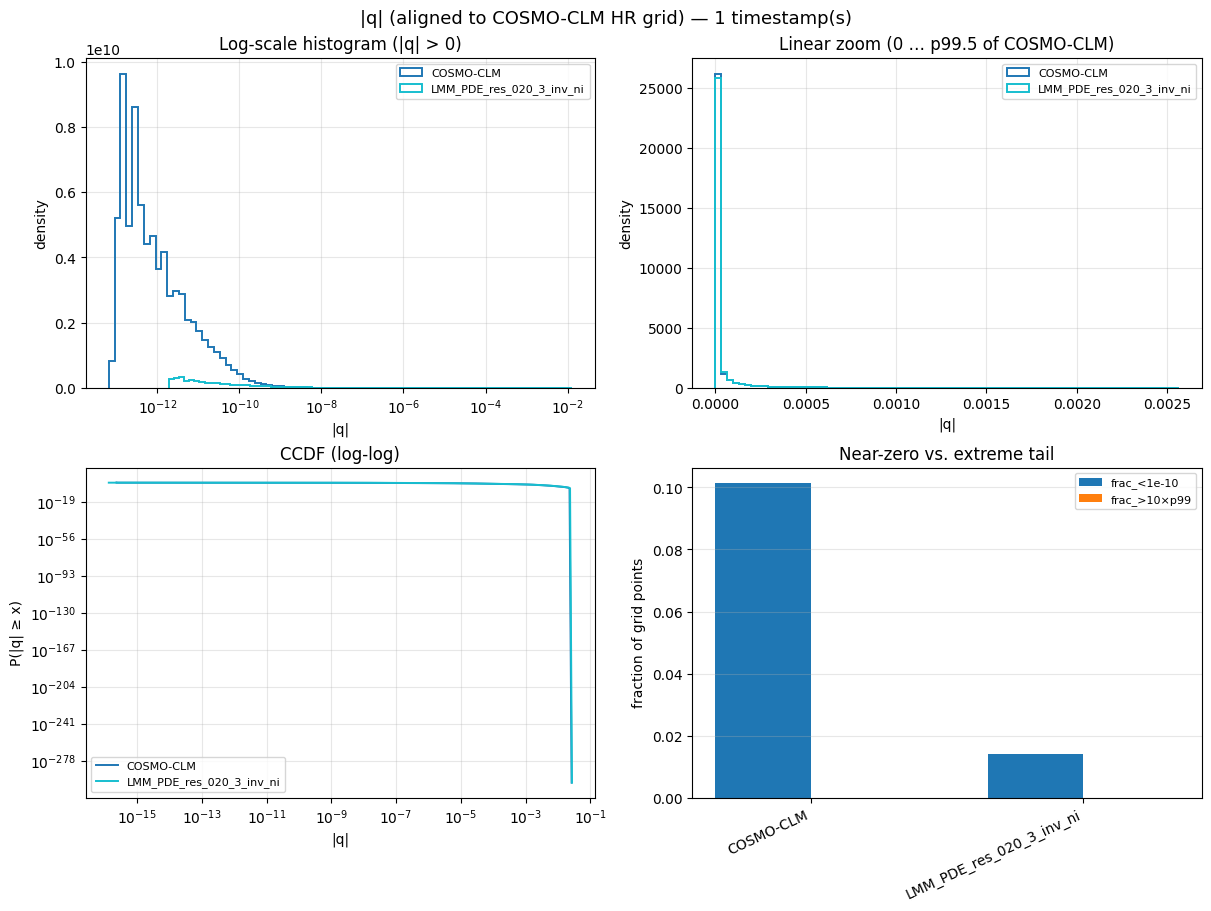

--- |grad T| (physical) ---


,field,n_pixels,min,p50,p90,p95,p99,p99.9,p99.99,max,frac_==0,frac_<1e-06,frac_>10×p99
model,,,,,,,,,,,,,
COSMO-CLM,|grad T|,387072,0.000000,0.004726,0.044594,0.065809,0.116496,0.175757,0.226019,0.297200,0.000036,0.000036,0.0
LMM_PDE_res_020_3_inv_ni,|grad T|,387072,0.000005,0.006561,0.046633,0.067738,0.118888,0.183256,0.233830,0.299582,0.000000,0.000000,0.0


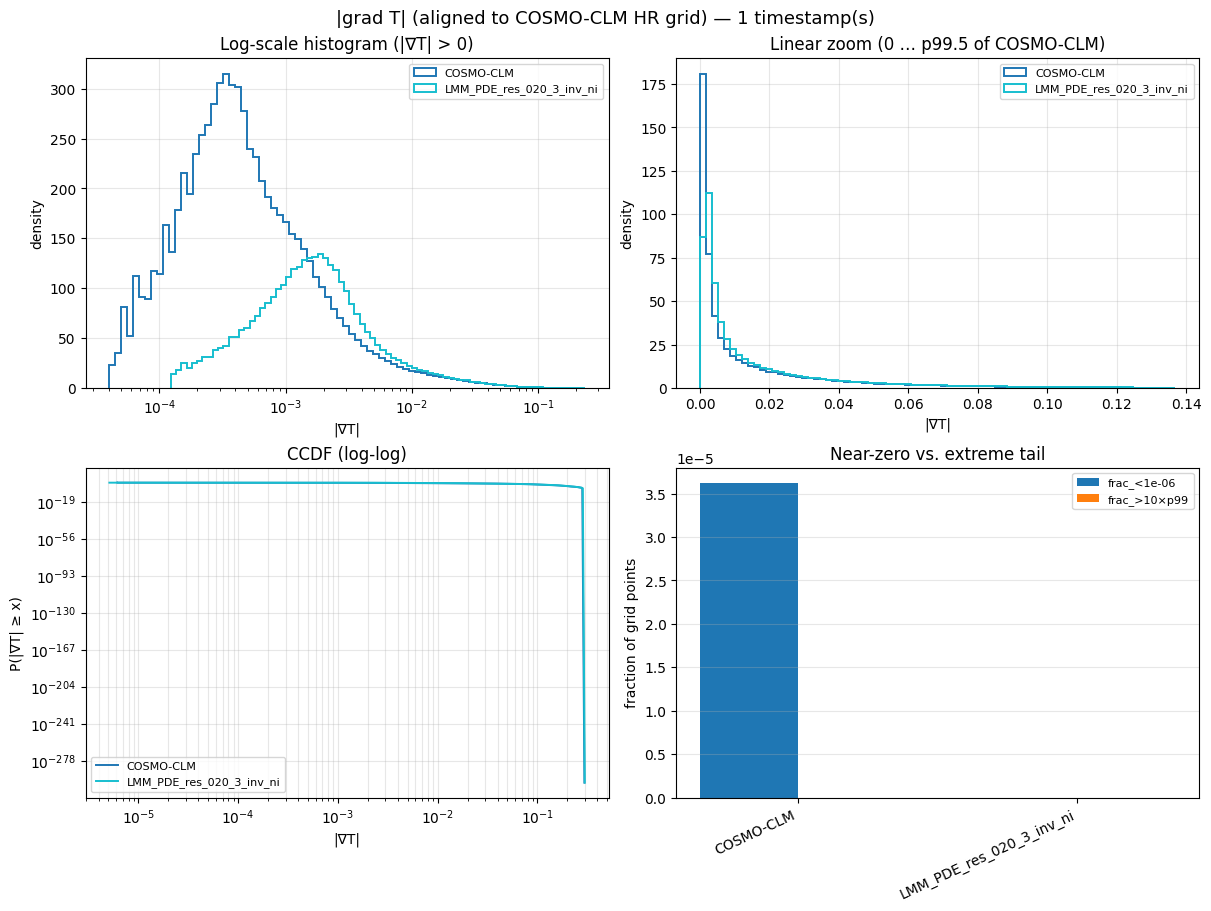

--- trace(J) (physical) ---


,field,n_pixels,min,p50,p90,p95,p99,p99.9,p99.99,max,frac_==0,frac_>10×p99
model,,,,,,,,,,,,
COSMO-CLM,trace(J),387072,0.000000e+00,0.000022,0.001989,0.004331,0.013571,0.030890,0.051085,0.088328,0.000036,0.0
LMM_PDE_res_020_3_inv_ni,trace(J),387072,2.619345e-11,0.000043,0.002175,0.004588,0.014134,0.033583,0.054676,0.089749,0.000000,0.0


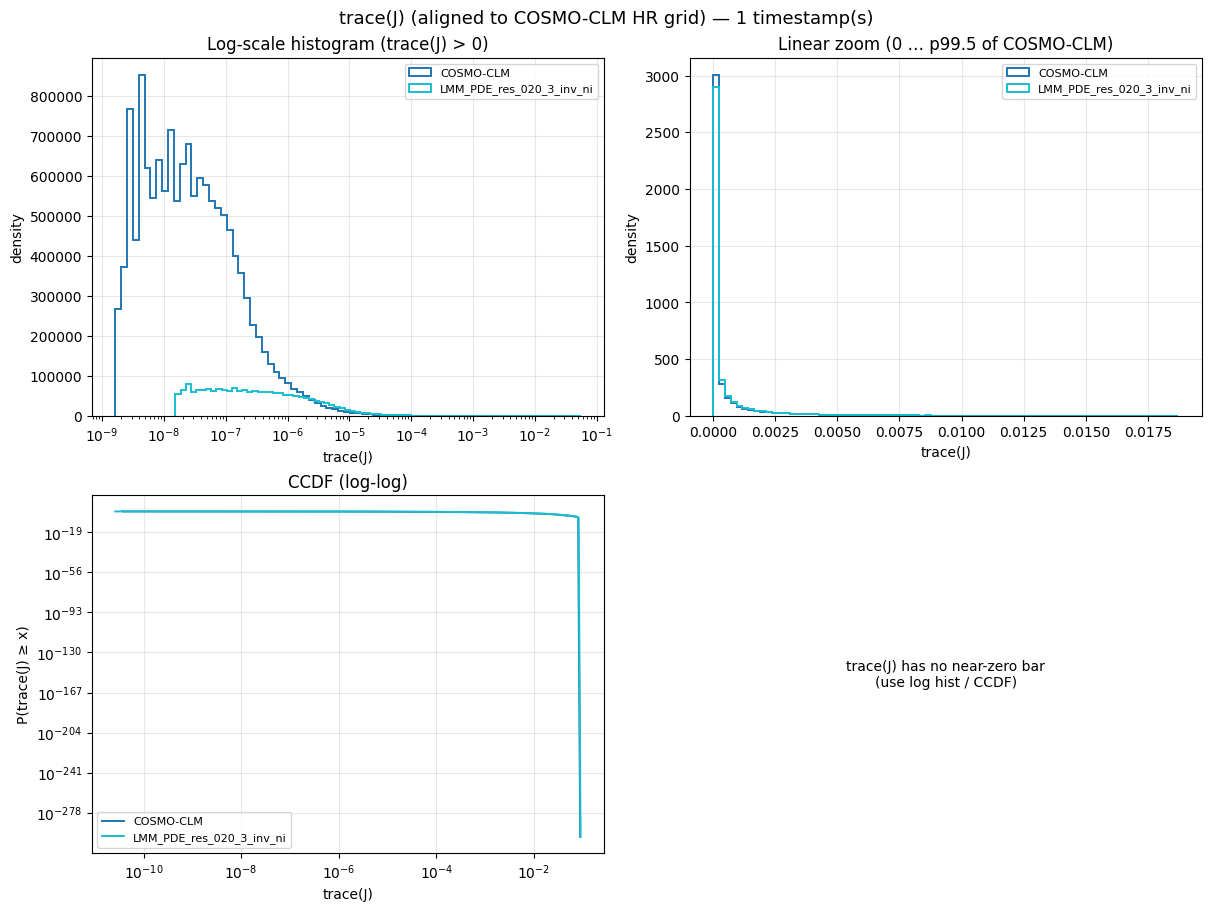

,value
compare,LMM_PDE_res_020_3_inv_ni vs COSMO-CLM @ 2014-0...
|q| phys min/max (m0),0.000e+00 / 2.625e-02
|q| phys min/max (m1),1.341e-16 / 2.689e-02
|q| phys dynamic range m0/m1,115453795108115.83 / 200565836349768.88
|q| sqrt+eps (both ~0.001?),0.001000 / 0.026270 | 0.001000 / 0.026906
L_total,12.784256
L_mag,11.475856
L_dir,1.308399
flux_mse_legacy,0.0
rel_mse vs mean|q_gt|²,0.37199


If sqrt+eps min≈max≈0.001 but phys |q| spans ~1e-11–1e-8, the old histogram was wrong. If lens ratio ≫ phys dynamic range, arrow length differences are mostly the display lens.


In [128]:
import matplotlib.pyplot as plt

ALIGN_TO_GT_GRID = GT_MODEL is not None
NEAR_ZERO_Q = 1e-10
NEAR_ZERO_GRAD = 1e-6
TAIL_MULT = 10.0

models_for_dist = [m for m in model_order if m in set(plot_df['model'].unique())]
if not models_for_dist:
    raise ValueError('No models from model_order found in plot_df.')

FIELD_SPECS = [
    ('|q|', 'q_mag', '|q|', NEAR_ZERO_Q),
    ('|grad T|', 'grad_mag', '|∇T|', NEAR_ZERO_GRAD),
    ('trace(J)', 'J_trace', 'trace(J)', 0.0),
]

mag_by_field = {key: {} for _, key, _, _ in FIELD_SPECS}
mag_eps_by_model = {}


def _collect_flux_scalars(model: str) -> dict[str, np.ndarray]:
    chunks = {key: [] for _, key, _, _ in FIELD_SPECS}
    q_eps_chunks = []
    for ts in selected_times:
        T = get_temperature_field(plot_df, model, ts)
        if ALIGN_TO_GT_GRID and GT_MODEL is not None:
            T_gt = get_temperature_field(plot_df, GT_MODEL, ts)
            if T.shape != T_gt.shape:
                T = upsample_to_reference_grid(T, T_gt.shape, label=model)
        flux = compute_flux_fields(T, dx=dx, dy=dy, eps=grad_eps)
        chunks['q_mag'].append(flux['q_mag'].ravel())
        chunks['grad_mag'].append(flux['grad_mag'].ravel())
        chunks['J_trace'].append(flux['J_trace'].ravel())
        q_eps_chunks.append(flux['q_mag_eps'].ravel())
    out = {key: np.concatenate(chunks[key]) for key in chunks}
    out['q_mag_eps'] = np.concatenate(q_eps_chunks)
    return out


def _scalar_stats(values: np.ndarray, label: str, near_zero: float) -> dict:
    pcts = np.percentile(values, [50, 90, 95, 99, 99.9, 99.99])
    p99 = pcts[3]
    row = {
        'field': label,
        'n_pixels': len(values),
        'min': float(np.nanmin(values)),
        'p50': pcts[0],
        'p90': pcts[1],
        'p95': pcts[2],
        'p99': pcts[3],
        'p99.9': pcts[4],
        'p99.99': pcts[5],
        'max': float(np.nanmax(values)),
        'frac_==0': float(np.mean(values == 0)),
    }
    if near_zero > 0:
        row[f'frac_<{near_zero:g}'] = float(np.mean(values < near_zero))
    if p99 > 0:
        row[f'frac_>{TAIL_MULT:g}×p99'] = float(np.mean(values > TAIL_MULT * p99))
    return row


def _plot_magnitude_distribution(
    mag_by_model: dict[str, np.ndarray],
    stats_df: pd.DataFrame,
    *,
    title: str,
    x_label: str,
    grid_note: str,
    near_zero_col: str | None,
):
    models = list(mag_by_model.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    fig.suptitle(f'{title} ({grid_note}) — {len(selected_times)} timestamp(s)', fontsize=13)

    ax = axes[0, 0]
    for c, model in zip(colors, models):
        v = mag_by_model[model]
        v_pos = v[v > 0]
        if v_pos.size == 0:
            continue
        lo, hi = np.percentile(v_pos, [0.1, 99.99])
        bins = np.logspace(np.log10(max(lo, 1e-30)), np.log10(max(hi, lo * 10)), 80)
        ax.hist(v_pos, bins=bins, density=True, histtype='step', linewidth=1.4, label=model, color=c)
    ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylabel('density')
    ax.set_title(f'Log-scale histogram ({x_label} > 0)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ref = mag_by_model[models[0]]
    pos_ref = ref[ref > 0]
    x_hi = float(np.percentile(pos_ref if pos_ref.size else ref, 99.5))
    if x_hi <= 0:
        x_hi = float(np.nanmax(ref)) or 1.0
    bins_lin = np.linspace(0.0, x_hi, 80)
    for c, model in zip(colors, models):
        ax.hist(mag_by_model[model], bins=bins_lin, density=True, histtype='step', linewidth=1.4, label=model, color=c)
    ax.set_xlabel(x_label)
    ax.set_ylabel('density')
    ax.set_title(f'Linear zoom (0 … p99.5 of {models[0]})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    for c, model in zip(colors, models):
        v = np.sort(mag_by_model[model][mag_by_model[model] > 0])
        if v.size == 0:
            continue
        ccdf = 1.0 - (np.arange(1, v.size + 1) / v.size)
        ax.loglog(v, ccdf + 1e-300, label=model, color=c, linewidth=1.4)
    ax.set_xlabel(x_label)
    ax.set_ylabel(f'P({x_label} ≥ x)')
    ax.set_title('CCDF (log-log)')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

    ax = axes[1, 1]
    if near_zero_col and near_zero_col in stats_df.columns:
        x = np.arange(len(models))
        w = 0.35
        tail_col = f'frac_>{TAIL_MULT:g}×p99'
        near = [stats_df.loc[m, near_zero_col] for m in models]
        tail = [stats_df.loc[m, tail_col] if tail_col in stats_df.columns else 0.0 for m in models]
        ax.bar(x - w / 2, near, width=w, label=near_zero_col)
        if tail_col in stats_df.columns:
            ax.bar(x + w / 2, tail, width=w, label=tail_col)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=25, ha='right')
        ax.set_ylabel('fraction of grid points')
        ax.set_title('Near-zero vs. extreme tail')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)
    else:
        ax.axis('off')
        ax.text(0.5, 0.5, 'trace(J) has no near-zero bar\n(use log hist / CCDF)', ha='center', va='center')

    plt.show()


grid_note = f'aligned to {GT_MODEL} HR grid' if ALIGN_TO_GT_GRID and GT_MODEL else 'native grid per model'
sqrt_eps_floor = float(np.sqrt(grad_eps))

for model in models_for_dist:
    scalars = _collect_flux_scalars(model)
    for _, key, _, _ in FIELD_SPECS:
        mag_by_field[key][model] = scalars[key]
    mag_eps_by_model[model] = scalars['q_mag_eps']

diag_rows = []
for model in models_for_dist:
    q = mag_by_field['q_mag'][model]
    q_eps = mag_eps_by_model[model]
    diag_rows.append({
        'model': model,
        '|q| max (physical)': float(q.max()),
        '|q| max (sqrt+eps floor)': float(q_eps.max()),
        f'frac |q|_phys < sqrt(grad_eps)={sqrt_eps_floor:g}': float(np.mean(q < sqrt_eps_floor)),
        'frac |q|_eps == sqrt(grad_eps)': float(np.mean(np.isclose(q_eps, sqrt_eps_floor))),
    })
print('--- eps floor diagnostic (why old histograms looked flat at 0.001) ---')
display(pd.DataFrame(diag_rows).set_index('model'))

FLAT_EPS_WARN = float(np.sqrt(grad_eps))
for field_title, key, x_label, near_zero in FIELD_SPECS:
    stats_rows = []
    for model in models_for_dist:
        row = _scalar_stats(mag_by_field[key][model], field_title, near_zero)
        row['model'] = model
        stats_rows.append(row)
    stats_df = pd.DataFrame(stats_rows).set_index('model')
    near_col = f'frac_<{near_zero:g}' if near_zero > 0 else None
    print(f'--- {field_title} (physical) ---')
    if key == 'q_mag':
        for m in models_for_dist:
            r = stats_df.loc[m]
            if abs(r['min'] - FLAT_EPS_WARN) / FLAT_EPS_WARN < 0.01 and abs(r['max'] - FLAT_EPS_WARN) / FLAT_EPS_WARN < 0.01:
                print(
                    f'  WARNING {m}: min/max ≈ {FLAT_EPS_WARN:g} — you may be viewing sqrt(|q|²+grad_eps), '
                    'not physical |q|. Re-run compute_flux_fields cell above.'
                )
    display(stats_df)
    _plot_magnitude_distribution(
        mag_by_field[key],
        stats_df,
        title=field_title,
        x_label=x_label,
        grid_note=grid_note,
        near_zero_col=near_col,
    )

# --- Reconcile histogram vs MSE vs lens (one timestamp) ---
if len(selected_times) and len(models_for_dist) >= 2:
    ts0 = selected_times[0]
    m0, m1 = models_for_dist[0], models_for_dist[1]
    if m0 != m1:
        T0 = get_temperature_field(plot_df, m0, ts0)
        T1 = get_temperature_field(plot_df, m1, ts0)
        if ALIGN_TO_GT_GRID and GT_MODEL is not None:
            Tg = get_temperature_field(plot_df, GT_MODEL, ts0)
            if T0.shape != Tg.shape:
                T0 = upsample_to_reference_grid(T0, Tg.shape, m0)
            if T1.shape != Tg.shape:
                T1 = upsample_to_reference_grid(T1, Tg.shape, m1)
        f0 = compute_flux_fields(T0, dx=dx, dy=dy, eps=grad_eps)
        f1 = compute_flux_fields(T1, dx=dx, dy=dy, eps=grad_eps)
        q0, q1 = f0['q_mag'], f1['q_mag']
        q0e, q1e = f0['q_mag_eps'], f1['q_mag_eps']
        pos0, pos1 = q0[q0 > 0], q1[q1 > 0]
        dyn0 = (pos0.max() / pos0.min()) if pos0.size else np.nan
        dyn1 = (pos1.max() / pos1.min()) if pos1.size else np.nan
        losses0 = flux_combined_loss(
            f1['qx'], f1['qy'], f0['qx'], f0['qy'],
            lambda_mag=FLUX_LAMBDA_MAG,
            lambda_dir=FLUX_LAMBDA_DIR,
            eps=FLUX_LOSS_EPS,
            direction_kind=FLUX_DIR_LOSS,
        )
        mse0 = flux_mse_legacy(f1['qx'], f1['qy'], f0['qx'], f0['qy'])
        eg = float(np.mean(f0['qx'] ** 2 + f0['qy'] ** 2))
        from utils.plotting_utils import _vectors_for_quiver_display
        q0lx, q0ly, _, _ = _vectors_for_quiver_display(
            f0['qx'], f0['qy'], None, use_lens=True,
            magnitude_gamma=0.45, min_arrow_frac=0.15, max_arrow_frac=1.0,
        )
        q1lx, q1ly, _, _ = _vectors_for_quiver_display(
            f1['qx'], f1['qy'], None, use_lens=True,
            magnitude_gamma=0.45, min_arrow_frac=0.15, max_arrow_frac=1.0,
        )
        lens_dyn = float(
            np.nanmax(np.hypot(q1lx, q1ly)) / max(np.nanmax(np.hypot(q0lx, q0ly)), 1e-30)
        )
        display(pd.DataFrame([{
            'compare': f'{m1} vs {m0} @ {ts0}',
            '|q| phys min/max (m0)': f'{q0.min():.3e} / {q0.max():.3e}',
            '|q| phys min/max (m1)': f'{q1.min():.3e} / {q1.max():.3e}',
            '|q| phys dynamic range m0/m1': f'{dyn0:.2f} / {dyn1:.2f}',
            '|q| sqrt+eps (both ~0.001?)': f'{q0e.min():.6f} / {q0e.max():.6f}  |  {q1e.min():.6f} / {q1e.max():.6f}',
            'L_total': losses0['L_total'],
            'L_mag': losses0['L_mag'],
            'L_dir': losses0['L_dir'],
            'flux_mse_legacy': mse0,
            'rel_mse vs mean|q_gt|²': mse0 / (eg + 1e-30),
            'lens display max|q| ratio m1/m0': lens_dyn,
        }]).T.rename(columns={0: 'value'}))
        print(
            'If sqrt+eps min≈max≈0.001 but phys |q| spans ~1e-11–1e-8, the old histogram was wrong. '
            'If lens ratio ≫ phys dynamic range, arrow length differences are mostly the display lens.'
        )


## |q| on normalized COSMO-CLM (training scale)

Apply ``(T - mean) / std`` from ``normalization_data.pkl`` (**CMCC** / **2mT**, same as LDM & LMM). Flux derivatives use the same ``dx, dy``; |q| is in **normalized** units (not Kelvin).


,source,variable,mean,std
0,CMCC,2mT,288.71225,8.29213


,space,min,p50,p90,p99,p99.9,max,frac_==0
0,physical [K flux units],0.0,1.055643e-07,8.867855e-05,0.001581,0.005429,0.026251,0.000036
1,normalized (training),0.0,1.851479e-10,1.555322e-07,0.000003,0.000010,0.000046,0.000036


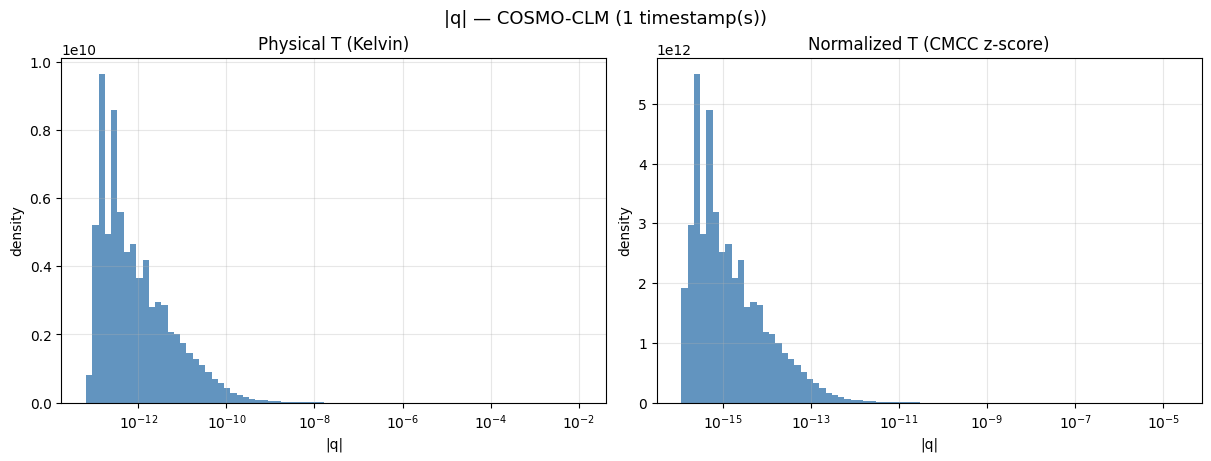

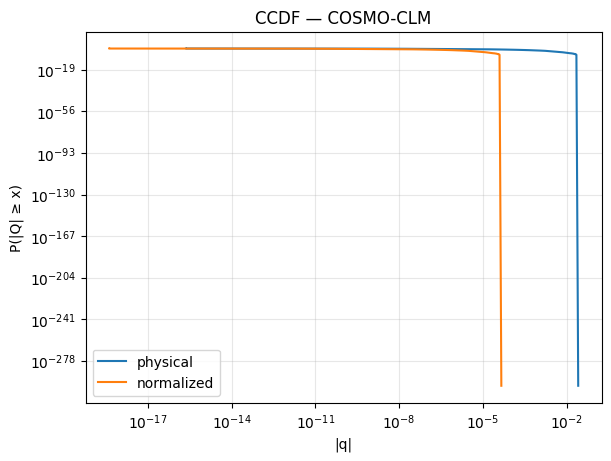

In [129]:
import matplotlib.pyplot as plt

from utils.temperature_normalization import (
    COSMO_SOURCE,
    default_normalization_pickle,
    load_norm_stats,
    normalize_temperature,
    norm_stats_summary,
)

NORM_PKL = default_normalization_pickle(NOTEBOOK_DIR.parent)
norm_values = load_norm_stats(NORM_PKL)
display(pd.DataFrame([norm_stats_summary(norm_values, PLOT_VAR, COSMO_SOURCE)]))

COSMO_MODEL = GT_MODEL if GT_MODEL is not None else 'COSMO-CLM'
if COSMO_MODEL not in set(plot_df['model'].unique()):
    raise ValueError(f'{COSMO_MODEL!r} not in plot_df; load it via model_order first.')

mag_raw = []
mag_norm = []
for ts in selected_times:
    T_phys = get_temperature_field(plot_df, COSMO_MODEL, ts)
    T_n = normalize_temperature(T_phys, variable=PLOT_VAR, source=COSMO_SOURCE, norm_values=norm_values)
    f_phys = compute_flux_fields(T_phys, dx=dx, dy=dy, eps=grad_eps)
    f_norm = compute_flux_fields(T_n, dx=dx, dy=dy, eps=grad_eps)
    mag_raw.append(f_phys['q_mag'].ravel())
    mag_norm.append(f_norm['q_mag'].ravel())

q_raw = np.concatenate(mag_raw)
q_norm = np.concatenate(mag_norm)

def _q_summary(label: str, q: np.ndarray) -> dict:
    p = np.percentile(q, [50, 90, 99, 99.9])
    return {
        'space': label,
        'min': float(np.min(q)),
        'p50': p[0],
        'p90': p[1],
        'p99': p[2],
        'p99.9': p[3],
        'max': float(np.max(q)),
        'frac_==0': float(np.mean(q == 0)),
    }

display(pd.DataFrame([_q_summary('physical [K flux units]', q_raw), _q_summary('normalized (training)', q_norm)]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
fig.suptitle(f'|q| — {COSMO_MODEL} ({len(selected_times)} timestamp(s))', fontsize=13)

for ax, q, title in zip(
    axes,
    [q_raw, q_norm],
    ['Physical T (Kelvin)', 'Normalized T (CMCC z-score)'],
):
    q_pos = q[q > 0]
    if q_pos.size:
        lo, hi = np.percentile(q_pos, [0.1, 99.99])
        bins = np.logspace(np.log10(max(lo, 1e-30)), np.log10(max(hi, lo * 10)), 80)
        ax.hist(q_pos, bins=bins, density=True, color='steelblue', alpha=0.85)
    ax.set_xscale('log')
    ax.set_xlabel('|q|')
    ax.set_ylabel('density')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.show()

# CCDF overlay: tail comparison
fig2, ax2 = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
for q, label, c in [(q_raw, 'physical', 'C0'), (q_norm, 'normalized', 'C1')]:
    v = np.sort(q[q > 0])
    if v.size:
        ccdf = 1.0 - (np.arange(1, v.size + 1) / v.size)
        ax2.loglog(v, ccdf + 1e-300, label=label, color=c, linewidth=1.5)
ax2.set_xlabel('|q|')
ax2.set_ylabel('P(|Q| ≥ x)')
ax2.set_title(f'CCDF — {COSMO_MODEL}')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)
plt.show()

## Plot flux snapshots (WS10 layout)

Panels **E–F**: `J_trace` = trace(recovered **J**), not real **K**.
Reload `plotting_utils` after edits.

Set `Q_MASK_SKIP_QUANTILE_PCT` in the config cell (masked points = **purple dots**). Row 1 has three **q** panels: domain (A), zoom (B), **deep zoom (G)** — tune `Q_DEEP_ZOOM_X/Y` and `Q_DEEP_ZOOM_STRIDE` to inspect quantile masking locally.


[COSMO-CLM] q mask: skip bottom 45% |q| (|q| <= 4.550e-08) -> 174182/387072 pixels (45.0%)
[LMM_PDE_res_020_3_inv_ni] q mask: skip bottom 45% |q| (|q| <= 1.465e-07) -> 174182/387072 pixels (45.0%)


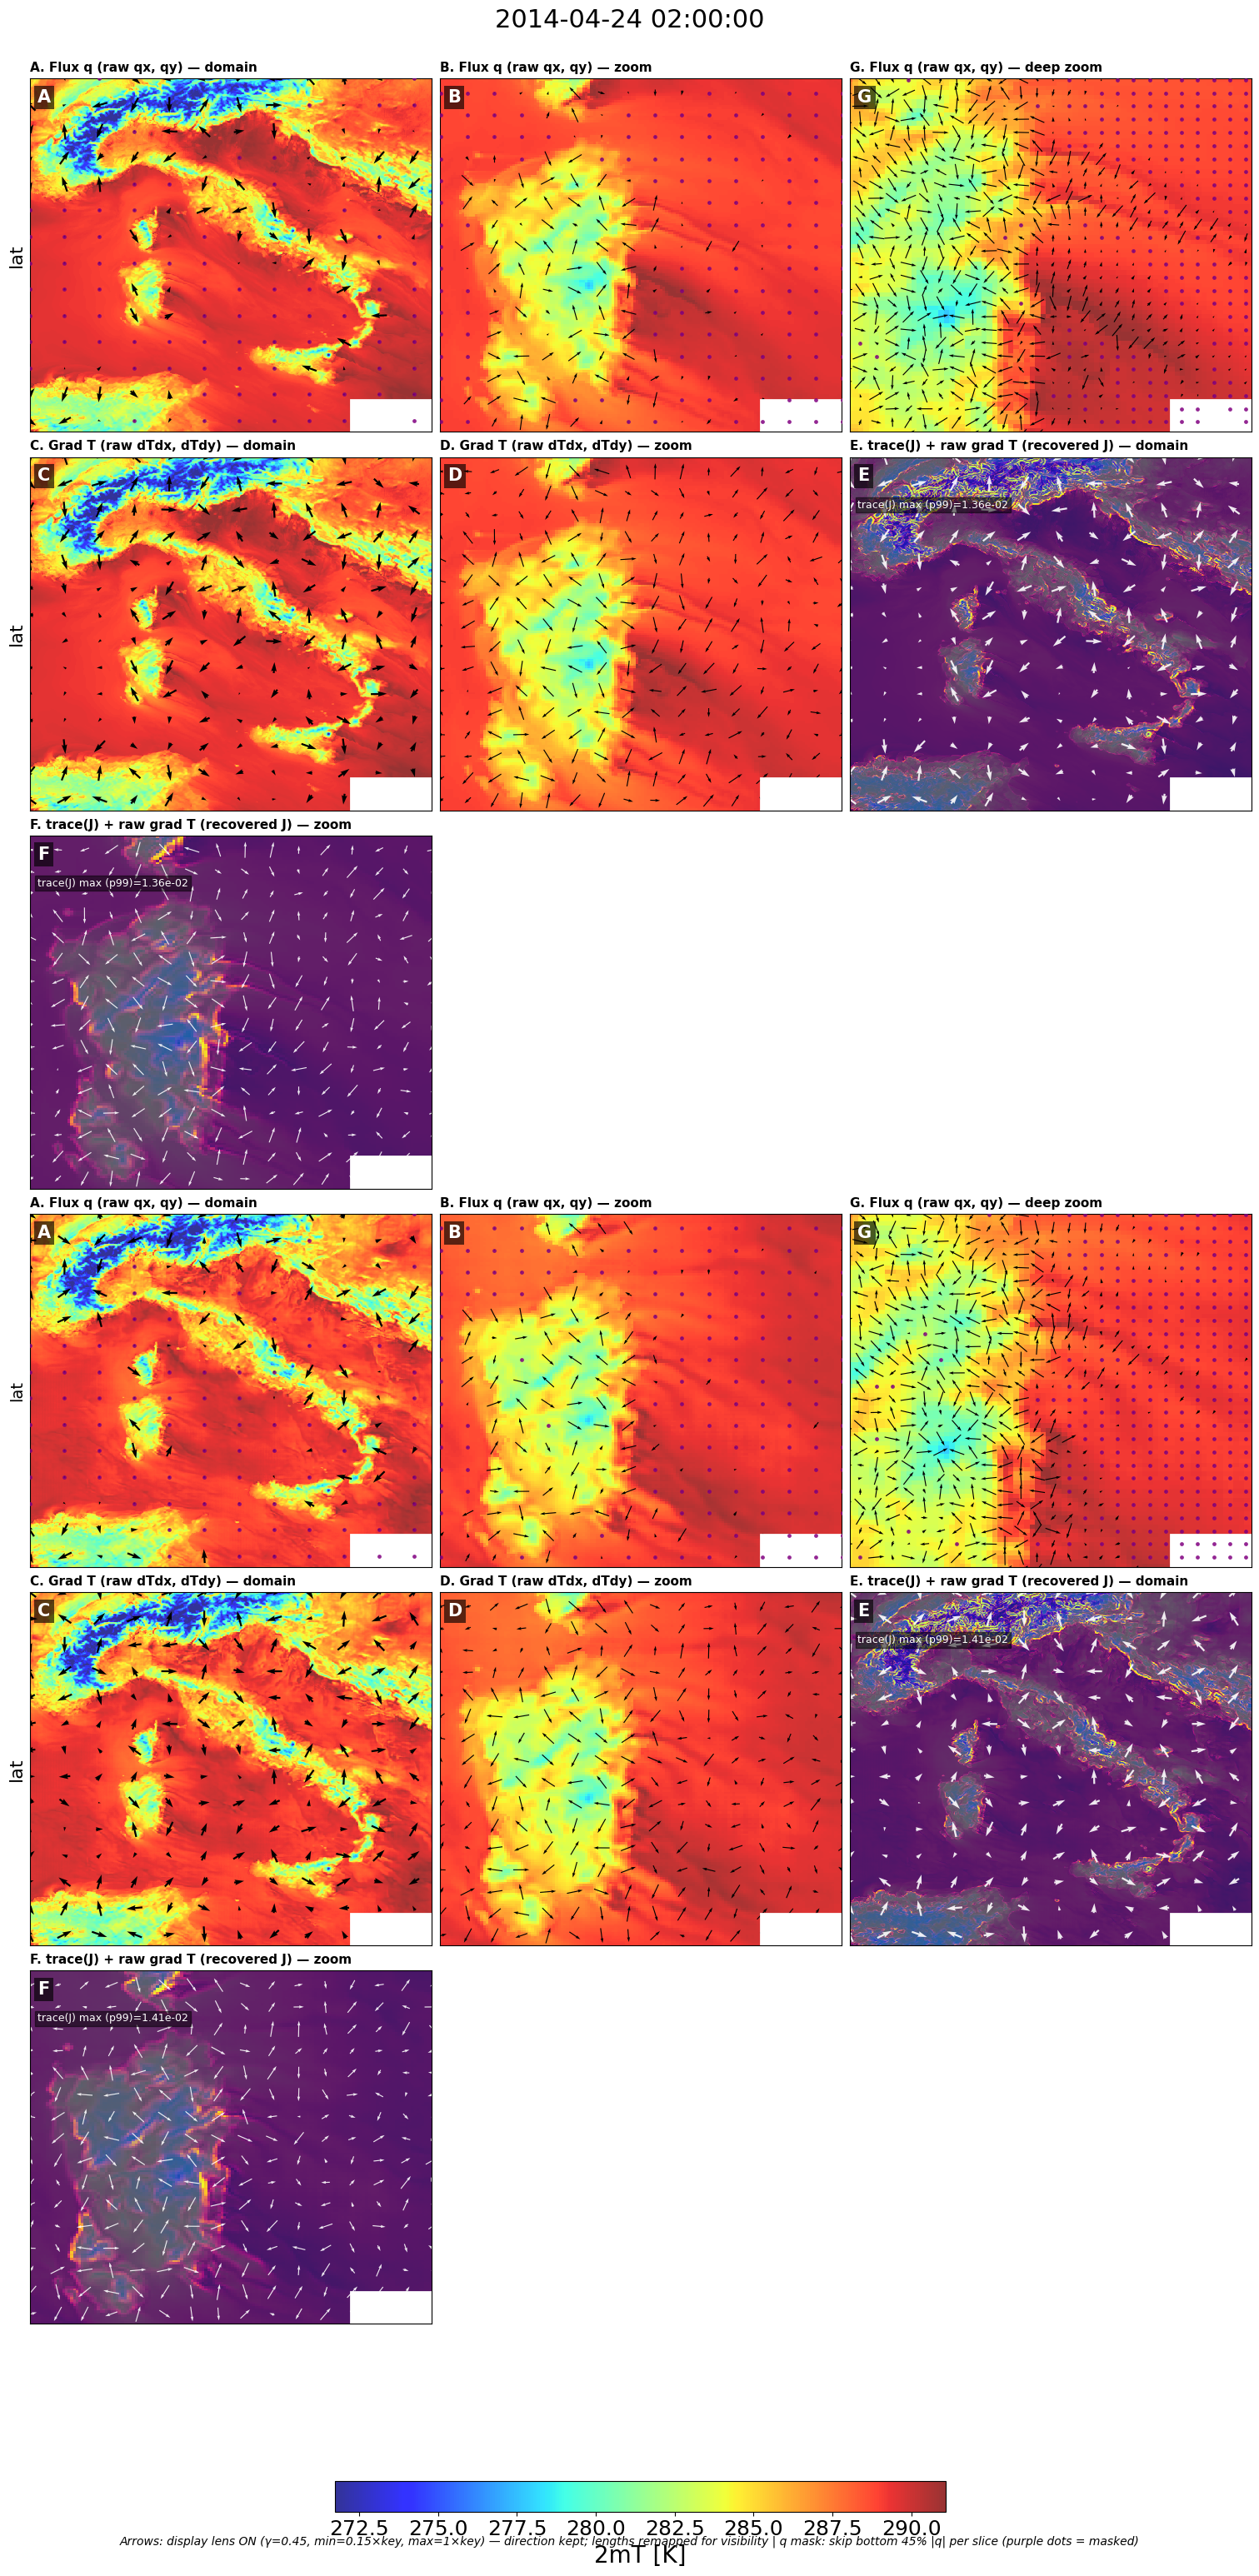

In [130]:
import importlib
import utils.plotting_utils as plotting_utils
importlib.reload(plotting_utils)
from utils.plotting_utils import show_q_snapshots


for ts in selected_times:
    ts_df = plot_df[pd.to_datetime(plot_df['time_step']) == pd.to_datetime(ts)]
    flux_by_model = {}
    for model in ts_df['model'].unique():
        T = get_temperature_field(plot_df, model, ts)
        flux_by_model[model] = compute_flux_fields(T, dx=dx, dy=dy, eps=grad_eps)
    show_q_snapshots(
        ts_df,
        flux_by_model,
        variable=PLOT_VAR,
        main_title=str(ts),
        borders_file=str(BORDERS_FILE) if BORDERS_FILE else None,
        output_dir=None,
        use_quiver_lens=USE_QUIVER_LENS,
        display_magnitude_gamma=0.45,
        display_min_arrow_frac=0.15,
        display_max_arrow_frac=1.0,
        q_mask_skip_quantile_pct=Q_MASK_SKIP_QUANTILE_PCT,
        q_deep_zoom_x=Q_DEEP_ZOOM_X,
        q_deep_zoom_y=Q_DEEP_ZOOM_Y,
        q_deep_zoom_stride=Q_DEEP_ZOOM_STRIDE,
    )



## Optional: PyTorch loss snippet


In [131]:
import torch
import torch.nn.functional as F

def _torch_flux_q(T, dx, dy):
    if T.dim() == 4:
        T = T[:, 0]
    B, H, W = T.shape
    dTdx = torch.zeros_like(T)
    dTdy = torch.zeros_like(T)
    if W > 2:
        dTdx[:, :, 1:-1] = (T[:, :, 2:] - T[:, :, :-2]) / (2 * dx)
    if H > 2:
        dTdy[:, 1:-1, :] = (T[:, 2:, :] - T[:, :-2, :]) / (2 * dy)
    if W > 1:
        dTdx[:, :, 0] = (T[:, :, 1] - T[:, :, 0]) / dx
        dTdx[:, :, -1] = (T[:, :, -1] - T[:, :, -2]) / dx
    if H > 1:
        dTdy[:, 0, :] = (T[:, 1, :] - T[:, 0, :]) / dy
        dTdy[:, -1, :] = (T[:, -1, :] - T[:, -2, :]) / dy
    J_xx = dTdx * dTdx
    J_xy = dTdx * dTdy
    J_yy = dTdy * dTdy
    qx = -(J_xx * dTdx + J_xy * dTdy)
    qy = -(J_xy * dTdx + J_yy * dTdy)
    return qx, qy


def anisotropic_flux_combined_loss(
    T_pred,
    T_gt,
    dx=1.0,
    dy=1.0,
    *,
    lambda_mag: float = 1.0,
    lambda_dir: float = 1.0,
    eps: float = 1e-12,
    direction_kind: str = "cosine",
):
    qx, qy = _torch_flux_q(T_pred, dx, dy)
    qx_g, qy_g = _torch_flux_q(T_gt, dx, dy)
    mag_p = torch.hypot(qx, qy)
    mag_g = torch.hypot(qx_g, qy_g)
    l_mag = F.mse_loss(torch.log(mag_p + eps), torch.log(mag_g + eps))
    if direction_kind == "cosine":
        dot = qx * qx_g + qy * qy_g
        cos = dot / (mag_p * mag_g + eps)
        l_dir = (1.0 - cos).mean()
    elif direction_kind == "unit_mse":
        px, py = qx / (mag_p + eps), qy / (mag_p + eps)
        gx, gy = qx_g / (mag_g + eps), qy_g / (mag_g + eps)
        l_dir = F.mse_loss(px, gx) + F.mse_loss(py, gy)
    else:
        raise ValueError(direction_kind)
    l_total = lambda_mag * l_mag + lambda_dir * l_dir
    return l_total, {"L_mag": l_mag, "L_dir": l_dir, "L_total": l_total}